# Food production data - supplementary analysis

This notebook supplements **tasks 2 and 3** with the course-supplied Food Bank crop data. Only records with `Element == "Production"` are retained, and their unit is checked to be tonnes. Equal units do **not** make production levels directly comparable across areas and products: area size, crop type and possible regional aggregates still matter.

The figures document missing-value treatment and the effect of a log transformation. The Student Graduation notebook remains the main analysis for encoding, scaling, splitting and PCA.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import MaxNLocator
from textwrap import fill

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12})
BLUE, ORANGE, GREEN = "#0072B2", "#D55E00", "#009E73"

## 1. Load and inspect the data

Read in chunks and retain only production records. The original values are preserved for comparison. Stop on ambiguous area-product-year keys rather than silently combining records. Zero production is treated as an observation, not as missing data.

In [2]:
# Set this path to the course-supplied crop file if it is stored elsewhere.
data_path = Path("../data/crop1.csv")
if not data_path.exists():
    data_path = Path("data/crop1.csv")
if not data_path.exists():
    raise FileNotFoundError("Place the course-supplied crop1.csv in data/, or update data_path.")

required_columns = ["Area", "Item", "Element", "Year", "Unit", "Value"]
parts = []
for chunk in pd.read_csv(data_path, usecols=required_columns, chunksize=250_000):
    production = chunk.loc[chunk["Element"].eq("Production")]
    if not production.empty:
        parts.append(production)
if not parts:
    raise ValueError("No Production records were found.")
food = pd.concat(parts, ignore_index=True)
if food[["Area", "Item", "Year", "Unit"]].isna().any().any():
    raise ValueError("Missing series keys or units need inspection before preprocessing.")
if set(food["Unit"].unique()) != {"tonnes"}:
    raise ValueError("Production records must all use tonnes for this analysis.")
food["Year"] = pd.to_numeric(food["Year"], errors="raise")
food["Value"] = pd.to_numeric(food["Value"], errors="raise")
if not np.isfinite(food["Year"]).all() or (food["Year"] % 1 != 0).any():
    raise ValueError("Expected finite integer years.")
if not np.isfinite(food["Value"].dropna()).all() or (food["Value"].dropna() < 0).any():
    raise ValueError("Non-finite or negative production values need inspection.")
if food.duplicated(["Area", "Item", "Year"]).any():
    raise ValueError("Duplicate area-product-year records need inspection.")
food = food.sort_values(["Area", "Item", "Year"]).reset_index(drop=True)
food["Value_original"] = food["Value"].copy()
display(food[required_columns].head())

,Area,Item,Element,Year,Unit,Value
0,Afghanistan,"Almonds, with shell",Production,1975,tonnes,0.0
1,Afghanistan,"Almonds, with shell",Production,1976,tonnes,9800.0
2,Afghanistan,"Almonds, with shell",Production,1977,tonnes,9000.0
3,Afghanistan,"Almonds, with shell",Production,1978,tonnes,12000.0
4,Afghanistan,"Almonds, with shell",Production,1979,tonnes,10500.0


In [3]:
print("Production records:", f"{len(food):,}")
print("Years:", food["Year"].min(), "to", food["Year"].max())
print("Areas:", food["Area"].nunique(), "| Products:", food["Item"].nunique())
print("Units:", food["Unit"].unique().tolist())
print("Zero production observations:", int(food["Value_original"].eq(0).sum()))
display(food[required_columns].isna().sum().rename("Missing records").to_frame())
display(food["Value_original"].describe().to_frame("Original production (tonnes)"))

Production records: 663,735
Years: 1961 to 2020
Areas: 245 | Products: 118
Units: ['tonnes']
Zero production observations: 5135


,Missing records
Area,0
Item,0
Element,0
Year,0
Unit,0
Value,56617


,Original production (tonnes)
count,6.071180e+05
mean,2.478627e+06
std,2.333034e+07
min,0.000000e+00
25%,3.476000e+03
50%,3.322000e+04
75%,2.811800e+05
max,1.955308e+09


## 2. Handling missing values

### Method and assumptions
Interpolate only **between observed values in the same area-product series**, weighting by the actual year. Fill only gaps spanning **at most three missing calendar years** (at most four years between supporting observations). This explicit, conservative choice avoids drawing straight lines across decades; it is a modelling assumption, not a universally optimal threshold. Unrestricted interpolation in this file bridged a 47-year interval. The comparison below reports how the limit changes the outcome. This assumes an approximately linear change over the accepted gap. It respects local scale better than a single global mean or median, but may smooth genuine shocks and becomes less reliable across long gaps.

Do not extrapolate before the first or after the last known value. Rows that remain missing, including rejected long gaps, are removed because there is insufficient local temporal information. This may disproportionately remove poorly covered areas/products; the missingness and retention figures make the size of this choice visible. Only missing `Value` cells in existing records are filled; entirely absent year records are not created.

This is retrospective data cleaning. Interpolation can use a later observation, so it must not be used unchanged for forecasting when that future observation would be unavailable.

In [4]:
MAX_MISSING_YEARS = 3

def interpolate_by_year(values, max_missing_years=MAX_MISSING_YEARS):
    """Fill internal gaps using year distances, while preserving the row index."""
    years = food.loc[values.index, "Year"].to_numpy()
    time_series = pd.Series(values.to_numpy(dtype=float), index=years)
    filled = time_series.interpolate(method="index", limit_area="inside")
    if max_missing_years is not None:
        observed_years = pd.Series(years.astype(float), index=years).where(time_series.notna())
        span = observed_years.bfill() - observed_years.ffill()
        allowed = time_series.notna() | (span <= max_missing_years + 1)
        filled = filled.where(allowed)
    return pd.Series(filled.to_numpy(), index=values.index)

missing_before = int(food["Value_original"].isna().sum())
unrestricted_values = food.groupby(["Area", "Item"], sort=False)["Value_original"].transform(
    lambda values: interpolate_by_year(values, max_missing_years=None)
)
unrestricted_filled = int((food["Value_original"].isna() & unrestricted_values.notna()).sum())
food["Value"] = food.groupby(["Area", "Item"], sort=False)["Value_original"].transform(
    interpolate_by_year
)
food["Was_imputed"] = food["Value_original"].isna() & food["Value"].notna()
missing_after = int(food["Value"].isna().sum())
food_clean = food.dropna(subset=["Value"]).copy()
if food_clean.empty:
    raise ValueError("No observed or interpolated production values remain.")

# Check that observed values are unchanged and every row is accounted for.
observed = food["Value_original"].notna()
assert food.loc[observed, "Value"].equals(food.loc[observed, "Value_original"])
assert int(food["Was_imputed"].sum()) + missing_after == missing_before
assert len(food_clean) + missing_after == len(food)

missing_treatment = pd.DataFrame({
    "Records": [int(observed.sum()), int(food["Was_imputed"].sum()), missing_after]
}, index=["Originally observed", "Interpolated", "Removed (still missing)"])
missing_treatment["Share of input (%)"] = missing_treatment["Records"] / len(food) * 100
display(missing_treatment.round(2))
print(f"Initially missing: {missing_before:,} ({missing_before / len(food):.2%})")
print(f"Rows retained: {len(food_clean):,} ({len(food_clean) / len(food):.2%})")
print(f"Without a gap limit: {unrestricted_filled:,} values would be filled.")
print(f"Rejected because the gap is too long: {unrestricted_filled - int(food['Was_imputed'].sum()):,}")
del unrestricted_values

,Records,Share of input (%)
Originally observed,607118,91.47
Interpolated,120,0.02
Removed (still missing),56497,8.51


Initially missing: 56,617 (8.53%)
Rows retained: 607,238 (91.49%)
Without a gap limit: 1,494 values would be filled.
Rejected because the gap is too long: 1,374


### Figure 1. Missingness over time and the treatment outcome
The left panel uses the number of existing records in each year as the denominator; it does not measure entirely absent area-product-year combinations. The right panel separates filled and removed records **among the initially missing values**, so even a small interpolation count remains visible.

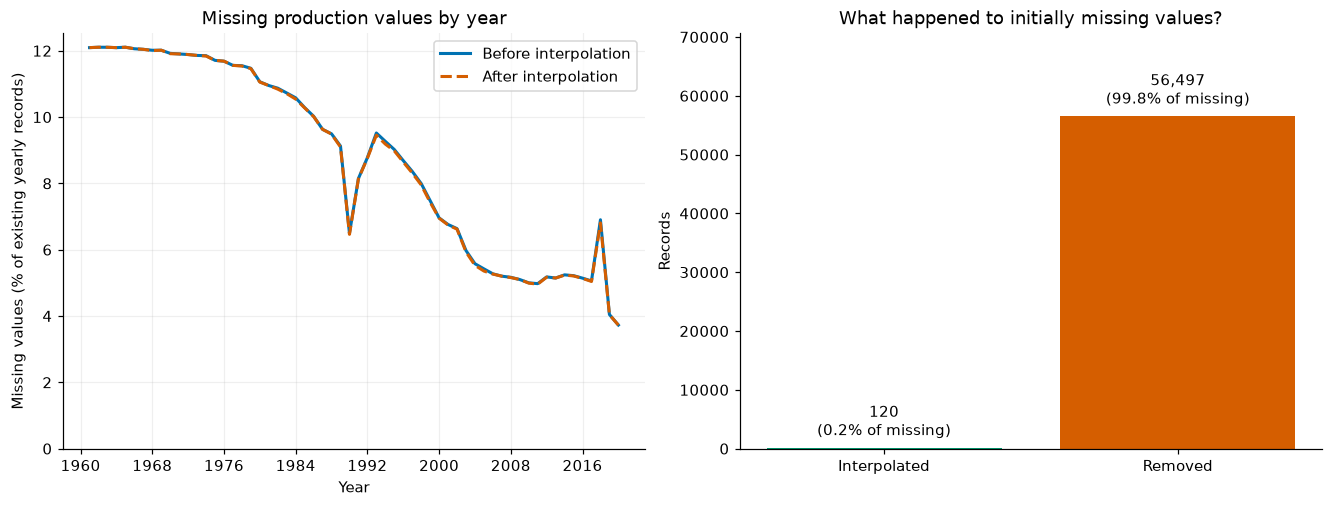

In [5]:
yearly_missing = food.assign(
    Missing_before=food["Value_original"].isna(),
    Missing_after=food["Value"].isna()
).groupby("Year")[["Missing_before", "Missing_after"]].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
axes[0].plot(yearly_missing.index, yearly_missing["Missing_before"], color=BLUE,
             label="Before interpolation", linewidth=2)
axes[0].plot(yearly_missing.index, yearly_missing["Missing_after"], color=ORANGE,
             label="After interpolation", linestyle="--", linewidth=2)
axes[0].set(title="Missing production values by year", xlabel="Year",
            ylabel="Missing values (% of existing yearly records)")
axes[0].set_ylim(bottom=0)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend()
axes[0].grid(alpha=0.2)
if missing_before:
    values = [int(food["Was_imputed"].sum()), missing_after]
    bars = axes[1].bar(["Interpolated", "Removed"], values, color=[GREEN, ORANGE])
    axes[1].bar_label(bars, labels=[f"{v:,}\n({v / missing_before:.1%} of missing)" for v in values], padding=5)
    axes[1].set(title="What happened to initially missing values?", ylabel="Records",
                ylim=(0, max(values) * 1.25))
else:
    axes[1].text(0.5, 0.5, "No missing values to treat", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()
plt.show()

### Figure 2. An actual interpolation example
Choose the area-product series with the most interpolated records (ties use alphabetical order). This is an illustrative case, not a random or representative sample. Original observations and estimated values have different markers. Shaded bands mark gaps between observed years; their widths show how much time the interpolation bridges. Any missing records left unfilled are marked at the bottom of the plot, not at zero production.

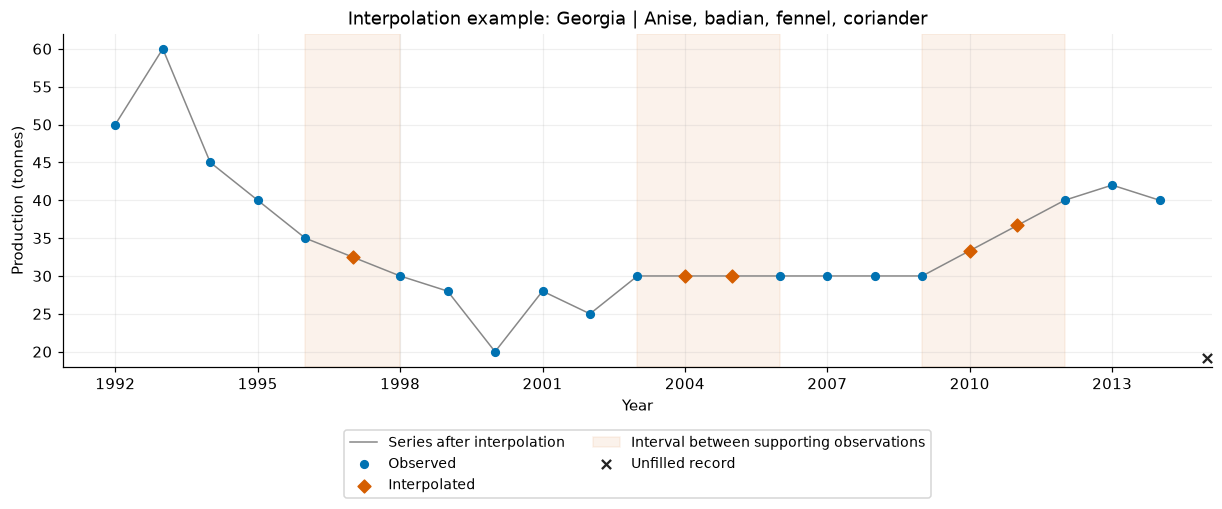

Time between supporting observations in this example: [2, 3, 3] years


In [6]:
imputed_by_series = food.groupby(["Area", "Item"], sort=True)["Was_imputed"].sum()
if imputed_by_series.max() > 0:
    example_area, example_item = imputed_by_series.idxmax()
    example = food.loc[food["Area"].eq(example_area) & food["Item"].eq(example_item)].copy()
    observed_example = example["Value_original"].notna()
    known_years = example.loc[observed_example, "Year"].to_numpy()
    filled_years = example.loc[example["Was_imputed"], "Year"].to_numpy()
    positions = np.searchsorted(known_years, filled_years)
    gap_bounds = sorted(set(zip(known_years[positions - 1], known_years[positions])))
    fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
    ax.plot(example["Year"], example["Value"], color="#888888", linewidth=1,
            label="Series after interpolation")
    ax.scatter(example.loc[observed_example, "Year"], example.loc[observed_example, "Value_original"],
               color=BLUE, s=25, zorder=3, label="Observed")
    ax.scatter(example.loc[example["Was_imputed"], "Year"], example.loc[example["Was_imputed"], "Value"],
               color=ORANGE, marker="D", s=35, zorder=4, label="Interpolated")
    for i, (start, end) in enumerate(gap_bounds):
        ax.axvspan(start, end, color=ORANGE, alpha=0.08,
                   label="Interval between supporting observations" if i == 0 else None)
    unresolved = example["Value"].isna()
    if unresolved.any():
        ax.scatter(example.loc[unresolved, "Year"], np.full(unresolved.sum(), 0.025),
                   transform=ax.get_xaxis_transform(), marker="x", color="#222222", label="Unfilled record")
    ax.set(title=fill(f"Interpolation example: {example_area} | {example_item}", 85),
           xlabel="Year", ylabel="Production (tonnes)")
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
    plt.show()
    print("Time between supporting observations in this example:",
          [int(end - start) for start, end in gap_bounds], "years")
else:
    print("No internal gaps were filled; there is no interpolation example to plot.")

## 3a. Detecting potential outliers

Apply the 1.5 x IQR rule to the retained production values, including interpolated values. This provides an overall screening result. **A pooled threshold combines different areas, products and years**, so it can flag structural scale differences rather than recording errors. Areas may also include overlapping regional aggregates; no world-production total is inferred by adding all rows.

The IQR rule is less sensitive to extreme observations than a mean/standard-deviation rule, but it is not a test of validity. A more targeted investigation would compare a flagged record with the same area's product history and check its source. The flagged-record table below retains that context and identifies imputed values.

In [7]:
q1 = food_clean["Value"].quantile(0.25)
q3 = food_clean["Value"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
food_clean["IQR_outlier"] = (
    (food_clean["Value"] < lower_limit) | (food_clean["Value"] > upper_limit)
)
print(f"IQR bounds: {lower_limit:,.2f} to {upper_limit:,.2f} tonnes")
print(f"Potential outliers: {food_clean['IQR_outlier'].sum():,} ({food_clean['IQR_outlier'].mean():.2%})")
if iqr == 0:
    print("IQR is zero: flags mainly reflect values different from the central mass.")
display(food_clean.loc[food_clean["IQR_outlier"]].nlargest(10, "Value")[
    ["Area", "Item", "Year", "Value", "Was_imputed"]
])

IQR bounds: -412,879.12 to 697,379.88 tonnes
Potential outliers: 101,942 (16.79%)


,Area,Item,Year,Value,Was_imputed
652275,World,Sugar cane,2019,1.955308e+09,False
652274,World,Sugar cane,2018,1.935215e+09,False
652269,World,Sugar cane,2013,1.901504e+09,False
652270,World,Sugar cane,2014,1.885020e+09,False
652272,World,Sugar cane,2016,1.881399e+09,False
652271,World,Sugar cane,2015,1.875003e+09,False
652276,World,Sugar cane,2020,1.869715e+09,False
652273,World,Sugar cane,2017,1.835890e+09,False
652268,World,Sugar cane,2012,1.827433e+09,False
652267,World,Sugar cane,2011,1.789981e+09,False


## 3b. Handling extreme values with a transformation

Retain the flagged values: the pooled IQR result alone is insufficient evidence for removal or capping. This does **not** verify every extreme value as correct. Preserve production in tonnes and add `Value_log = log1p(Value)` to compress the scale of large observations. This transformation is defined at zero and can be reversed with `expm1`.

### Figure 3. Before and after log1p
Histograms show the complete distributions with **linear axes in each panel**: tonnes on the left and transformed units on the right. Box plots show the middle 50% and potential IQR outliers on each respective scale. The right-hand box plot calculates its whiskers in log space; its outlier markers therefore need not match the original-scale IQR flags. No observations are removed by the transformation.

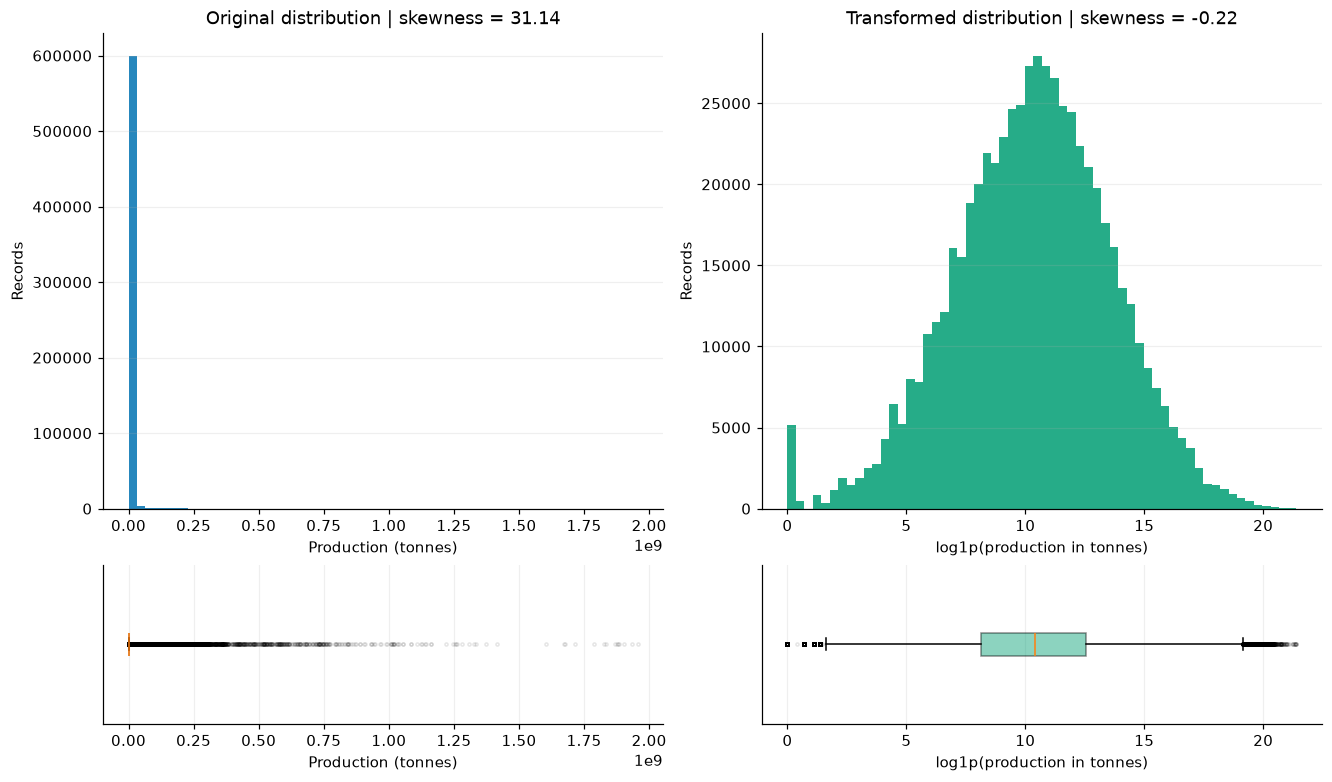

Skewness: 31.14 before; -0.22 after log1p.
All 607,238 retained records remain after transformation.


In [8]:
food_clean["Value_log"] = np.log1p(food_clean["Value"])
assert np.isfinite(food_clean["Value_log"]).all()
assert np.allclose(np.expm1(food_clean["Value_log"]), food_clean["Value"])
skew_before = food_clean["Value"].skew()
skew_after = food_clean["Value_log"].skew()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained",
                         gridspec_kw={"height_ratios": [3, 1]})
for j, (column, label, color, skewness) in enumerate([
    ("Value", "Production (tonnes)", BLUE, skew_before),
    ("Value_log", "log1p(production in tonnes)", GREEN, skew_after)
]):
    values = food_clean[column]
    axes[0, j].hist(values, bins=60, color=color, alpha=0.85)
    axes[0, j].set(title=f"{'Original' if j == 0 else 'Transformed'} distribution | skewness = {skewness:.2f}",
                   xlabel=label, ylabel="Records")
    axes[0, j].grid(axis="y", alpha=0.2)
    axes[1, j].boxplot(values, orientation="horizontal", whis=1.5, patch_artist=True,
                       boxprops={"facecolor": color, "alpha": 0.45},
                       flierprops={"markersize": 2, "alpha": 0.1})
    axes[1, j].set(xlabel=label, yticks=[])
    axes[1, j].grid(axis="x", alpha=0.2)
plt.show()
print(f"Skewness: {skew_before:.2f} before; {skew_after:.2f} after log1p.")
print(f"All {len(food_clean):,} retained records remain after transformation.")

The original histogram may concentrate almost entirely in the first bins when a few values are very large; this is a consequence of displaying the full range. Log1p reveals the distribution across orders of magnitude. A skewness closer to zero indicates greater symmetry, **not** proof of normality, removal of errors or improved model performance. The transformed feature would need to be evaluated in the intended modelling task.

## Conclusion

Missing production values are treated within their area-product time series; the figures show how many are filled and an example of the underlying assumption. Unsupported values are removed rather than extrapolated. A log feature compresses extreme production values without deleting them, while original tonnes and imputation provenance remain available for inspection. The global IQR flags are screening indicators, and neither interpolation nor transformation establishes that the source data are error-free.